# Instacart Smart Basket Completion
### IA-2 — Advanced Data Analytics (216H03C701), Semester VII, AY 2026–27

**Approved problem statement**

> **Identifying complementary and potentially missing grocery products in a customer's shopping basket using frequent itemset mining, association rules, purchase history, and recency-aware recommendation.**

This notebook is an **academic analogue** of Instacart's recommendation problem using the public Instacart Market Basket Analysis dataset. It investigates a layered recommendation pipeline rather than claiming that the algorithms below are Instacart's proprietary production implementation.

### End-to-end workflow
1. Load and validate Instacart data.
2. Explore basket and reorder behavior.
3. Build a leakage-resistant mining/validation split.
4. Mine frequent itemsets with **Apriori** and **FP-Growth**.
5. Generate association rules for complementary-product retrieval.
6. Build customer purchase-history features.
7. Add **recency, frequency, and reorder behavior**.
8. Generate personalized candidates from association rules.
9. Compare a rule-only baseline with a personalized, recency-aware recommender.
10. Evaluate on held-out next baskets using Hit@K, Precision@K, Recall@K, coverage, and diversity.
11. Analyze scalability, limitations, responsible AI, and future improvements.

> **Important:** Public Instacart documentation describes recommendation capabilities and co-purchase/relevance signals, but this notebook does not claim that Instacart uses Apriori or FP-Growth in production.

## 1. Install dependencies

The notebook is designed for Google Colab or a normal Python/Jupyter environment.

If automatic dataset download is unavailable, download the Instacart Market Basket Analysis CSV files and place them under `data/instacart/` or set `INSTACART_DATA_DIR` to the directory containing the CSV files.

In [1]:
%pip -q install "mlxtend>=0.23" "kagglehub>=0.3" "psutil>=5.9"

In [2]:
from __future__ import annotations

import os
import platform
import random
import time
import warnings
import zipfile
import hashlib
from pathlib import Path
from urllib.request import urlretrieve

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import psutil
import seaborn as sns

from IPython.display import display
from mlxtend.frequent_patterns import apriori, association_rules, fpgrowth

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")

SEED = 42

# Resource controls. Increase these only if your runtime has enough RAM/CPU.
MAX_ORDERS = 30_000
TOP_N_PRODUCTS = 250

MIN_SUPPORT = 0.003
MIN_CONFIDENCE = 0.10
MIN_LIFT = 1.05
MAX_ITEMSET_LEN = 3

TOP_K = 10

random.seed(SEED)
np.random.seed(SEED)

print({
    "python": platform.python_version(),
    "pandas": pd.__version__,
    "ram_gb": round(psutil.virtual_memory().total / 2**30, 1),
    "seed": SEED,
})

{'python': '3.13.15', 'pandas': '2.2.3', 'ram_gb': 12.7, 'seed': 42}


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 2. Load the Instacart Market Basket Analysis data

Required files:

- `orders.csv`
- `products.csv`
- `aisles.csv`
- `departments.csv`
- `order_products__prior.csv`
- `order_products__train.csv`

The public Kaggle competition dataset is used as the academic data source. The code first looks for a local directory, then tries a public GitHub bundle, Kaggle, and finally a public mirror.

In [3]:
REQUIRED = {
    "orders.csv",
    "products.csv",
    "aisles.csv",
    "departments.csv",
    "order_products__prior.csv",
    "order_products__train.csv",
}

def locate_csv_dir(root: Path) -> Path | None:
    candidates = [root] + [p for p in root.rglob("*") if p.is_dir()]
    for candidate in candidates:
        if REQUIRED.issubset({p.name for p in candidate.glob("*.csv")}):
            return candidate
    return None

DATA_ROOT = Path(os.environ.get("INSTACART_DATA_DIR", str(Path.cwd() / "data")))
DATA_ROOT.mkdir(parents=True, exist_ok=True)
DATA_DIR = locate_csv_dir(DATA_ROOT)

BUNDLE_NAME = "instacart-market-basket-analysis-data.zip"
BUNDLE_SHA256 = "b0c58b80af5c43bcdebf34909033b740fc312353d2b8aa5f442083c824e8311d"
BUNDLE_URL = (
    "https://github.com/shreejaykurhade/instacart-frequent-itemset-mining/"
    f"releases/download/dataset-v1/{BUNDLE_NAME}"
)

if DATA_DIR is None:
    try:
        bundle = Path.cwd() / BUNDLE_NAME
        if not bundle.exists():
            bundle = DATA_ROOT / BUNDLE_NAME
        if not bundle.exists():
            print("Downloading dataset bundle...")
            urlretrieve(BUNDLE_URL, bundle)

        with bundle.open("rb") as stream:
            digest = hashlib.file_digest(stream, "sha256").hexdigest()

        if digest != BUNDLE_SHA256:
            raise ValueError("Dataset bundle checksum mismatch.")

        with zipfile.ZipFile(bundle) as archive:
            if set(archive.namelist()) != REQUIRED:
                raise ValueError("Dataset bundle contains unexpected filenames.")
            archive.extractall(DATA_ROOT)

        DATA_DIR = locate_csv_dir(DATA_ROOT)
        print("Verified and extracted:", DATA_DIR)
    except Exception as exc:
        print("GitHub bundle unavailable:", exc)

if DATA_DIR is None:
    try:
        import kagglehub

        downloaded = Path(
            kagglehub.competition_download("instacart-market-basket-analysis")
        )

        if downloaded.is_file() and downloaded.suffix == ".zip":
            extract_to = DATA_ROOT / "instacart"
            extract_to.mkdir(exist_ok=True)
            with zipfile.ZipFile(downloaded) as archive:
                archive.extractall(extract_to)
            DATA_DIR = locate_csv_dir(extract_to)
        else:
            DATA_DIR = locate_csv_dir(downloaded)

        print("Kaggle data:", DATA_DIR)
    except Exception as exc:
        print("Kaggle download unavailable:", exc)

if DATA_DIR is None:
    try:
        mirror = (
            "https://huggingface.co/datasets/attik/"
            "Instacart-Market-Basket-Analysis/resolve/main"
        )
        mirror_dir = DATA_ROOT / "instacart"
        mirror_dir.mkdir(exist_ok=True)

        for filename in sorted(REQUIRED):
            destination = mirror_dir / filename
            if not destination.exists():
                print("Downloading:", filename)
                urlretrieve(f"{mirror}/{filename}", destination)

        DATA_DIR = locate_csv_dir(mirror_dir)
    except Exception as exc:
        print("Public mirror unavailable:", exc)

if DATA_DIR is None:
    raise FileNotFoundError(
        "Instacart CSVs not found. Upload/unzip the Kaggle archive under "
        f"{DATA_ROOT} or set INSTACART_DATA_DIR. Required: {sorted(REQUIRED)}"
    )

print("Using data from:", DATA_DIR)

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

GitHub bundle unavailable: HTTP Error 404: Not Found


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

Kaggle download unavailable: User is not authenticated
Downloading: aisles.csv


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

...

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

Downloading: products.csv


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

Using data from: /content/data/instacart


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

In [4]:
orders = pd.read_csv(
    DATA_DIR / "orders.csv",
    dtype={
        "order_id": "int32",
        "user_id": "int32",
        "eval_set": "category",
        "order_number": "int16",
        "order_dow": "int8",
        "order_hour_of_day": "int8",
        "days_since_prior_order": "float32",
    },
)

products = pd.read_csv(
    DATA_DIR / "products.csv",
    dtype={"product_id": "int32", "aisle_id": "int16", "department_id": "int8"},
)

aisles = pd.read_csv(DATA_DIR / "aisles.csv", dtype={"aisle_id": "int16"})
departments = pd.read_csv(
    DATA_DIR / "departments.csv", dtype={"department_id": "int8"}
)

prior = pd.read_csv(
    DATA_DIR / "order_products__prior.csv",
    dtype={
        "order_id": "int32",
        "product_id": "int32",
        "add_to_cart_order": "int16",
        "reordered": "int8",
    },
)

train = pd.read_csv(
    DATA_DIR / "order_products__train.csv",
    dtype={
        "order_id": "int32",
        "product_id": "int32",
        "add_to_cart_order": "int16",
        "reordered": "int8",
    },
)

assert orders.order_id.is_unique
assert products.product_id.is_unique
assert set(prior.order_id).issubset(set(orders.order_id))
assert prior[["order_id", "product_id"]].duplicated().sum() == 0

summary = pd.DataFrame({
    "table": ["orders", "prior items", "train items", "products", "users"],
    "rows_or_count": [
        len(orders),
        len(prior),
        len(train),
        len(products),
        orders.user_id.nunique(),
    ],
})

display(summary.style.format({"rows_or_count": "{:,}"}))

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

,table,rows_or_count
0,orders,"3,421,083"
1,prior items,"32,434,489"
2,train items,"1,384,617"
3,products,"49,688"
4,users,"206,209"


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

## 3. Understand the business data

The core recommendation signals available in the public dataset include:

- **Basket composition:** products bought together in the same order.
- **Customer history:** previous orders of the same user.
- **Order sequence:** `order_number`.
- **Inter-order timing:** `days_since_prior_order`.
- **Reorder behavior:** the `reordered` field.

The goal is not to reproduce Instacart's entire marketplace. The goal is to model the approved business problem: identify useful complementary or potentially missing products for a customer.

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

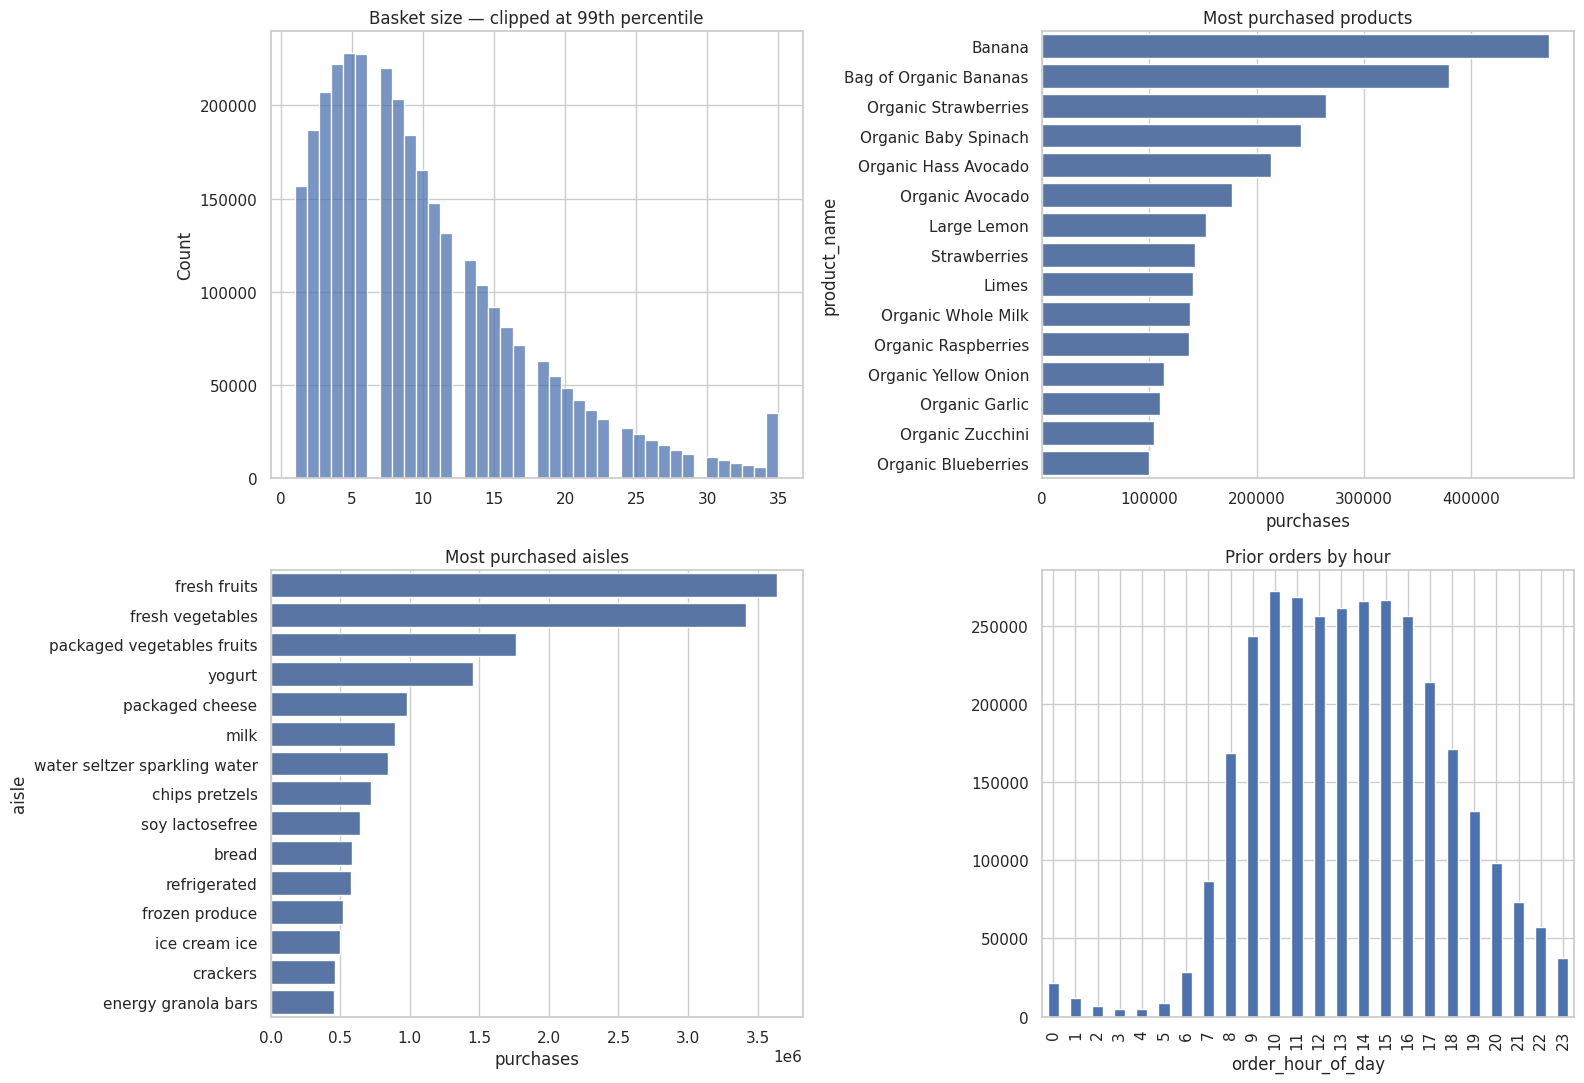

Median basket size: 8.0
Prior-item reorder rate: 0.5897


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

In [5]:
product_dim = (
    products
    .merge(aisles, on="aisle_id", how="left")
    .merge(departments, on="department_id", how="left")
)

prior_orders = orders.loc[
    orders.eval_set == "prior",
    ["order_id", "user_id", "order_number", "order_dow", "order_hour_of_day",
     "days_since_prior_order"],
]

prior_named = prior.merge(product_dim, on="product_id", how="left")

basket_sizes = prior.groupby("order_id", observed=True).size()

top_products = (
    prior_named.groupby(["product_id", "product_name"], observed=True)
    .size()
    .sort_values(ascending=False)
    .head(15)
    .rename("purchases")
    .reset_index()
)

top_aisles = (
    prior_named.groupby("aisle", observed=True)
    .size()
    .sort_values(ascending=False)
    .head(15)
    .rename("purchases")
    .reset_index()
)

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

sns.histplot(
    basket_sizes.clip(upper=basket_sizes.quantile(.99)),
    bins=40,
    ax=axes[0, 0],
)
axes[0, 0].set_title("Basket size — clipped at 99th percentile")

sns.barplot(data=top_products, y="product_name", x="purchases", ax=axes[0, 1])
axes[0, 1].set_title("Most purchased products")

sns.barplot(data=top_aisles, y="aisle", x="purchases", ax=axes[1, 0])
axes[1, 0].set_title("Most purchased aisles")

hourly = prior_orders.groupby("order_hour_of_day", observed=True).size()
hourly.plot(kind="bar", ax=axes[1, 1], title="Prior orders by hour")

plt.tight_layout()
plt.show()

print("Median basket size:", basket_sizes.median())
print("Prior-item reorder rate:", round(prior.reordered.mean(), 4))

## 4. Leakage-resistant development split

For each selected user, the **last prior order** is held out as the target basket.

- Earlier orders → mining/history
- Last prior order → validation target

This means the target basket is not used to create its own association rules or customer-history features.

The split is especially important because the project claims to predict a customer's next/held-out shopping basket.

In [6]:
last_prior = prior_orders.groupby(
    "user_id", observed=True
)["order_number"].transform("max")

order_split = prior_orders.assign(
    split=np.where(
        prior_orders.order_number.eq(last_prior),
        "validation",
        "mining",
    )
)

eligible_users = order_split.groupby("user_id", observed=True).size()
eligible_users = eligible_users[eligible_users >= 2].index.to_numpy()

rng = np.random.default_rng(SEED)

sampled_users = rng.choice(
    eligible_users,
    size=min(len(eligible_users), max(2_000, MAX_ORDERS // 5)),
    replace=False,
)

sampled_meta = order_split[order_split.user_id.isin(sampled_users)].copy()

# Keep all earlier orders for sampled users available for history.
mining_ids_all = sampled_meta.loc[
    sampled_meta.split == "mining", "order_id"
].to_numpy()

# Bound the global mining workload.
mining_ids = rng.choice(
    mining_ids_all,
    size=min(MAX_ORDERS, len(mining_ids_all)),
    replace=False,
)

validation_ids = sampled_meta.loc[
    sampled_meta.split == "validation", "order_id"
].to_numpy()

mining_items = prior[prior.order_id.isin(mining_ids)].copy()
validation_items = prior[prior.order_id.isin(validation_ids)].copy()

popular_ids = (
    mining_items.product_id
    .value_counts()
    .head(TOP_N_PRODUCTS)
    .index
)

mining_top = mining_items[
    mining_items.product_id.isin(popular_ids)
].copy()

name_map = product_dim.set_index("product_id").product_name.to_dict()

print({
    "mining_orders": mining_top.order_id.nunique(),
    "validation_orders": validation_items.order_id.nunique(),
    "products_retained": mining_top.product_id.nunique(),
    "mining_rows": len(mining_top),
})

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

{'mining_orders': 24423, 'validation_orders': 6000, 'products_retained': 250, 'mining_rows': 101746}


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

## 5. Sparse basket representation

Rows are orders and columns are retained products.

A sparse matrix is used because most products do not occur in most baskets.

In [7]:
basket = pd.crosstab(
    mining_top.order_id,
    mining_top.product_id
).astype(bool)

basket = basket.astype(pd.SparseDtype(bool, fill_value=False))
basket.columns = basket.columns.map(name_map)

density = float(basket.sparse.density)

print("Basket shape:", basket.shape)
print("Matrix density:", f"{density:.4%}")
print(
    "Sparse memory (MB):",
    round(basket.memory_usage(deep=True).sum() / 2**20, 2),
)

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

Basket shape: (24423, 250)
Matrix density: 1.6664%
Sparse memory (MB): 0.58


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

## 6. Frequent itemset mining — Apriori vs FP-Growth

Both algorithms receive the same transactions and thresholds.

- **Apriori:** explicit candidate-generation approach; useful for teaching and interpretability.
- **FP-Growth:** compresses frequent-pattern information and avoids the same style of repeated candidate generation.

The runtime benchmark below is only a benchmark for this sample and runtime, not a universal statement about which algorithm is always faster.

In [8]:
def timed_mine(function, matrix, **kwargs):
    start = time.perf_counter()
    result = function(matrix, **kwargs)
    return result, time.perf_counter() - start

params = dict(
    min_support=MIN_SUPPORT,
    use_colnames=True,
    max_len=MAX_ITEMSET_LEN,
    low_memory=True,
)

apriori_sets, apriori_seconds = timed_mine(
    apriori, basket, **params
)

fp_params = {
    k: v for k, v in params.items()
    if k != "low_memory"
}

fp_sets, fpgrowth_seconds = timed_mine(
    fpgrowth, basket, **fp_params
)

def canonical(df):
    return {
        (tuple(sorted(items)), round(float(support), 10))
        for support, items in zip(df.support, df.itemsets)
    }

agreement = canonical(apriori_sets) == canonical(fp_sets)

benchmark = pd.DataFrame({
    "algorithm": ["Apriori", "FP-Growth"],
    "seconds": [apriori_seconds, fpgrowth_seconds],
    "frequent_itemsets": [len(apriori_sets), len(fp_sets)],
})

display(benchmark)
print("Algorithms return identical itemsets/supports:", agreement)

assert agreement, (
    "Apriori and FP-Growth returned different itemsets/supports. "
    "Check package version and input matrix."
)

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

,algorithm,seconds,frequent_itemsets
0,Apriori,0.671091,707
1,FP-Growth,42.899400,707


Algorithms return identical itemsets/supports: True


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

## 7. Generate association rules

Rules are used as the **candidate retrieval layer**.

Example:

`{Milk, Bread} → {Butter}`

Interpretation:

> When Milk and Bread are present in a basket, Butter has an observed association with that combination.

We use:

- **Support** — how often the whole rule pattern occurs.
- **Confidence** — how often the consequent occurs when the antecedent occurs.
- **Lift** — how much stronger the relationship is than the consequent's baseline frequency.

A one-product consequent matches the next-item/product-completion task.

In [9]:
rules = association_rules(
    fp_sets,
    metric="confidence",
    min_threshold=MIN_CONFIDENCE,
)

rules = rules[
    (rules.lift >= MIN_LIFT)
    & (rules.consequents.map(len) == 1)
    & np.isfinite(rules.lift)
].copy()

rules["antecedent"] = rules.antecedents.map(
    lambda x: tuple(sorted(x))
)

rules["consequent"] = rules.consequents.map(
    lambda x: next(iter(x))
)

# Rule-only retrieval score.
rules["rule_score"] = (
    rules.confidence
    * np.log1p(rules.lift)
    * np.sqrt(rules.support)
)

rules = rules.sort_values(
    ["rule_score", "support"],
    ascending=False,
)

display(
    rules[
        [
            "antecedent",
            "consequent",
            "support",
            "confidence",
            "lift",
            "leverage",
            "conviction",
            "rule_score",
        ]
    ]
    .head(25)
    .style
    .format(precision=4)
)

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

,antecedent,consequent,support,confidence,lift,leverage,conviction,rule_score
251,"('Total 2% Lowfat Greek Strained Yogurt With Blueberry',)",Total 2% with Strawberry Lowfat Greek Strained Yogurt,0.0051,0.5869,42.5304,0.0050,2.3871,0.1584
252,"('Total 2% with Strawberry Lowfat Greek Strained Yogurt',)",Total 2% Lowfat Greek Strained Yogurt With Blueberry,0.0051,0.3709,42.5304,0.0050,1.5758,0.1001
254,"('Total 2% Lowfat Greek Strained Yogurt With Blueberry',)",Total 2% Lowfat Greek Strained Yogurt with Peach,0.0036,0.4178,43.0587,0.0036,1.7011,0.0955
212,"('Total 2% Lowfat Greek Strained Yogurt with Peach',)",Total 2% with Strawberry Lowfat Greek Strained Yogurt,0.0041,0.4219,30.5788,0.0040,1.7061,0.0932
253,"('Total 2% Lowfat Greek Strained Yogurt with Peach',)",Total 2% Lowfat Greek Strained Yogurt With Blueberry,0.0036,0.3755,43.0587,0.0036,1.5874,0.0858
482,"('Total 2% Greek Strained Yogurt with Cherry 5.3 oz',)",Total 2% with Strawberry Lowfat Greek Strained Yogurt,0.0032,0.3578,25.9303,0.0031,1.5357,0.0666
213,"('Total 2% with Strawberry Lowfat Greek Strained Yogurt',)",Total 2% Lowfat Greek Strained Yogurt with Peach,0.0041,0.2967,30.5788,0.0040,1.4081,0.0656
138,"('Organic Avocado',)",Banana,0.0228,0.3194,1.7361,0.0097,1.1990,0.0485
178,"('Organic Fuji Apple',)",Banana,0.0133,0.3741,2.0337,0.0067,1.3038,0.0478
370,"('Honeycrisp Apple',)",Banana,0.0117,0.3818,2.0756,0.0061,1.3201,0.0464


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

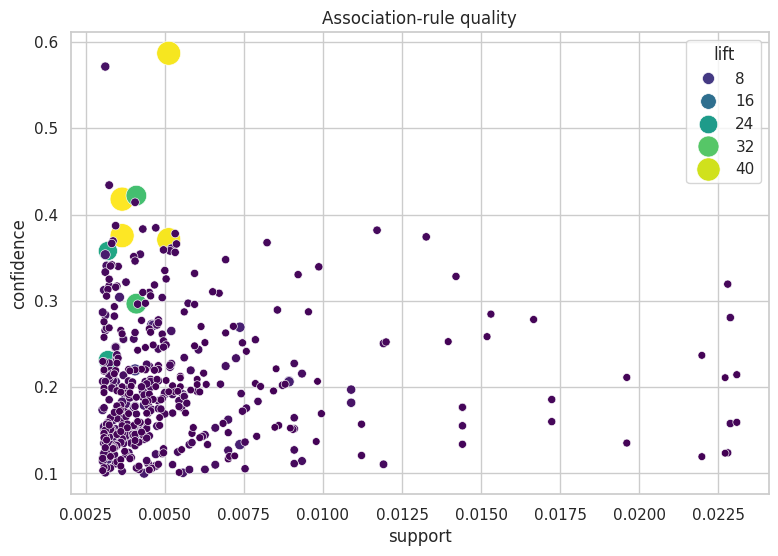

Number of usable rules: 464


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

In [10]:
fig, ax = plt.subplots(figsize=(9, 6))

if len(rules):
    sns.scatterplot(
        data=rules,
        x="support",
        y="confidence",
        size="lift",
        hue="lift",
        palette="viridis",
        sizes=(30, 300),
        ax=ax,
    )

ax.set_title("Association-rule quality")
plt.show()

print("Number of usable rules:", len(rules))

### Interpretation caution

High confidence can occur because a consequent is already popular. Lift helps correct for baseline popularity, while support prevents over-focusing on extremely rare patterns.

These statistics show **association**, not causation.

In [11]:
def recommend_rule_only(items, rule_frame=rules, k=10):
    """Retrieve complementary products using association rules only."""
    basket_set = set(items)

    candidates = rule_frame[
        rule_frame.antecedent.map(
            lambda a: set(a).issubset(basket_set)
        )
        & ~rule_frame.consequent.isin(basket_set)
    ].copy()

    if candidates.empty:
        return pd.DataFrame(
            columns=[
                "product_id",
                "product",
                "rule_score",
                "confidence",
                "lift",
            ]
        )

    result = (
        candidates
        .groupby("consequent", as_index=False)
        .agg(
            rule_score=("rule_score", "max"),
            confidence=("confidence", "max"),
            lift=("lift", "max"),
        )
        .sort_values("rule_score", ascending=False)
        .head(k)
        .rename(columns={"consequent": "product_id"})
    )

    result["product"] = result.product_id.map(name_map)
    return result[
        ["product_id", "product", "rule_score", "confidence", "lift"]
    ]

example_items = list(rules.iloc[0].antecedent) if len(rules) else []
print("Example basket:", example_items)
display(recommend_rule_only(example_items, k=TOP_K))

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

Example basket: ['Total 2% Lowfat Greek Strained Yogurt With Blueberry']


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,product_id,product,rule_score,confidence,lift
1,Total 2% with Strawberry Lowfat Greek Strained...,NaN,0.158426,0.586854,42.530405
0,Total 2% Lowfat Greek Strained Yogurt with Peach,NaN,0.095484,0.417840,43.058715


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

# 8. Customer purchase history and recency

This is the key extension required by the approved problem statement.

For each customer/product pair we calculate:

### Frequency
How many previous orders of the customer contained the product.

### Customer frequency ratio
The fraction of the customer's previous orders containing the product.

### Reorder tendency
The average `reordered` signal for that customer's previous purchases of the product.

### Recency
How many days have elapsed since the customer last purchased the product.

To calculate recency, we reconstruct an approximate customer shopping timeline from `days_since_prior_order`.

**Leakage rule:** only orders before the validation target are used to create customer-history features.

In [12]:
# Reconstruct an approximate elapsed-day timeline for each user's prior orders.
timeline = prior_orders.sort_values(
    ["user_id", "order_number"]
).copy()

timeline["gap_days"] = timeline["days_since_prior_order"].fillna(0).astype(float)

timeline["elapsed_days"] = (
    timeline.groupby("user_id", observed=True)["gap_days"]
    .cumsum()
)

# Useful lookup: order_id -> user/time information.
order_time = timeline.set_index("order_id")[
    ["user_id", "order_number", "elapsed_days"]
]

print(timeline.head())

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

   order_id  user_id  order_number  order_dow  order_hour_of_day  \
0   2539329        1             1          2                  8   
1   2398795        1             2          3                  7   
2    473747        1             3          3                 12   
3   2254736        1             4          4                  7   
4    431534        1             5          4                 15   

   days_since_prior_order  gap_days  elapsed_days  
0                     NaN       0.0           0.0  
1                    15.0      15.0          15.0  
2                    21.0      21.0          36.0  
3                    29.0      29.0          65.0  
4                    28.0      28.0          93.0  


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

In [13]:
# History includes all prior purchases before each validation order.
# For efficiency, we build features for the sampled validation users.

sampled_validation_meta = sampled_meta[
    sampled_meta.split == "validation"
].copy()

# Keep validation orders with a known immediately previous order.
order_lookup = orders.set_index(
    ["user_id", "order_number"]
).order_id

sampled_validation_meta["previous_order_id"] = [
    order_lookup.get((u, n - 1), np.nan)
    for u, n in zip(
        sampled_validation_meta.user_id,
        sampled_validation_meta.order_number,
    )
]

sampled_validation_meta = sampled_validation_meta.dropna(
    subset=["previous_order_id"]
).copy()

sampled_validation_meta["previous_order_id"] = (
    sampled_validation_meta["previous_order_id"].astype("int32")
)

# Restrict to validation users and all their prior order lines.
validation_users = set(sampled_validation_meta.user_id)

history_order_ids = set(
    prior_orders.loc[
        prior_orders.user_id.isin(validation_users),
        "order_id"
    ]
)

history_items = prior[
    prior.order_id.isin(history_order_ids)
].copy()

history_items = history_items.merge(
    timeline[
        ["order_id", "user_id", "order_number", "elapsed_days"]
    ],
    on="order_id",
    how="left",
)

history_items = history_items.merge(
    sampled_validation_meta[
        ["order_id", "user_id"]
    ].rename(columns={"order_id": "target_order_id"}),
    on="user_id",
    how="left",
)

# Only purchases before the target order.
history_items = history_items[
    history_items.order_number <
    history_items.groupby("user_id")["order_number"].transform("max")
]

print("History rows:", len(history_items))

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

History rows: 868831


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

In [14]:
# Replace the generic max-order filter with the exact validation target order.
target_order_numbers = sampled_validation_meta.set_index("user_id")["order_number"].to_dict()

history_items["target_order_number"] = history_items.user_id.map(
    target_order_numbers
)

history_items = history_items[
    history_items.order_number < history_items.target_order_number
].copy()

# Customer-product history features.
customer_product_history = (
    history_items
    .groupby(["user_id", "product_id"], observed=True)
    .agg(
        purchase_orders=("order_id", "nunique"),
        purchase_events=("product_id", "size"),
        last_order_number=("order_number", "max"),
        last_elapsed_day=("elapsed_days", "max"),
        reorder_rate=("reordered", "mean"),
    )
    .reset_index()
)

customer_order_counts = (
    history_items
    .groupby("user_id", observed=True)["order_id"]
    .nunique()
    .rename("customer_orders")
    .reset_index()
)

customer_product_history = customer_product_history.merge(
    customer_order_counts,
    on="user_id",
    how="left",
)

customer_product_history["frequency_ratio"] = (
    customer_product_history.purchase_orders
    / customer_product_history.customer_orders
)

target_time = sampled_validation_meta.set_index(
    "user_id"
)["order_number"]

target_elapsed = sampled_validation_meta.set_index(
    "user_id"
)["order_id"].map(
    order_time["elapsed_days"]
).to_dict()

customer_product_history["target_elapsed_day"] = (
    customer_product_history.user_id.map(target_elapsed)
)

customer_product_history["recency_days"] = (
    customer_product_history.target_elapsed_day
    - customer_product_history.last_elapsed_day
).clip(lower=0)

display(
    customer_product_history.head(15).style.format({
        "frequency_ratio": "{:.3f}",
        "reorder_rate": "{:.3f}",
        "recency_days": "{:.1f}",
    })
)

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

,user_id,product_id,purchase_orders,purchase_events,last_order_number,last_elapsed_day,reorder_rate,customer_orders,frequency_ratio,target_elapsed_day,recency_days
0,1,196,9,9,9,146.000000,0.889,9,1.000,176.000000,30.0
1,1,10258,8,8,9,146.000000,0.875,9,0.889,176.000000,30.0
2,1,10326,1,1,5,93.000000,0.000,9,0.111,176.000000,83.0
3,1,12427,9,9,9,146.000000,0.889,9,1.000,176.000000,30.0
4,1,13032,2,2,7,132.000000,0.500,9,0.222,176.000000,44.0
5,1,13176,2,2,5,93.000000,0.500,9,0.222,176.000000,83.0
6,1,14084,1,1,1,0.000000,0.000,9,0.111,176.000000,176.0
7,1,17122,1,1,5,93.000000,0.000,9,0.111,176.000000,83.0
8,1,25133,7,7,9,146.000000,0.857,9,0.778,176.000000,30.0
9,1,26088,2,2,2,15.000000,0.500,9,0.222,176.000000,161.0


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

## 9. Define a recency-aware personalized score

The recommender combines two kinds of evidence:

### A. Basket association evidence
From frequent itemsets and association rules:

- rule confidence
- lift
- support

### B. Customer behavior evidence
From the customer's history:

- purchase frequency
- frequency ratio
- reorder tendency
- recency

The final score is an **academic prototype scoring function**, not an Instacart production formula.

A simple weighted version is:

`final_score = rule_weight × rule_score + history_weight × history_score`

where recent purchases receive a higher recency component.

This gives us a clean experiment:

1. **Rule-only recommendation**
2. **Rule + purchase history**
3. **Rule + purchase history + recency**

That comparison directly tests whether personalization adds value.

In [16]:
# Convert rule statistics into a lookup table.
rule_lookup = rules.copy()

# Map the product names in consequent back to their product IDs
reverse_name_map = {name: pid for pid, name in name_map.items()}
rule_lookup["product_id"] = rule_lookup.consequent.map(reverse_name_map).astype("int64")

# For a product, keep the strongest applicable rule for each antecedent.
rule_lookup = rule_lookup[
    [
        "antecedent",
        "product_id",
        "rule_score",
        "confidence",
        "lift",
        "support",
    ]
].copy()

# Stable parameters for the academic prototype.
RULE_WEIGHT = 0.60
HISTORY_WEIGHT = 0.40
RECENCY_WEIGHT = 0.50

def _rule_candidates(items, rule_frame=rule_lookup):
    basket_set = set(items)

    if not basket_set or rule_frame.empty:
        return pd.DataFrame(
            columns=[
                "product_id",
                "rule_score",
                "confidence",
                "lift",
                "support",
            ]
        )

    # Here items are product_ids, so we need to map antecedent (names) back to product_ids
    # or convert the input items to names. Let's map antecedents to IDs for consistent comparisons.
    candidates = rule_frame[
        rule_frame.antecedent.map(
            lambda a: set(reverse_name_map.get(x) for x in a).issubset(basket_set)
        )
        & ~rule_frame.product_id.isin(basket_set)
    ].copy()

    if candidates.empty:
        return candidates

    return (
        candidates
        .sort_values(
            ["rule_score", "support"],
            ascending=False
        )
        .groupby("product_id", as_index=False)
        .first()
    )

def _attach_history(candidates, user_id, history_frame):
    if candidates.empty:
        return candidates

    user_hist = history_frame[
        history_frame.user_id.eq(user_id)
    ][
        [
            "product_id",
            "frequency_ratio",
            "reorder_rate",
            "recency_days",
        ]
    ].copy()

    out = candidates.merge(
        user_hist,
        on="product_id",
        how="left",
    )

    out["frequency_ratio"] = out["frequency_ratio"].fillna(0.0)
    out["reorder_rate"] = out["reorder_rate"].fillna(0.0)

    # New/unseen products receive zero historical recency score.
    # For previously purchased products, exponential decay gives
    # higher value to more recent behavior.
    out["recency_score"] = np.where(
        out["recency_days"].notna(),
        np.exp(-out["recency_days"] / 30.0),
        0.0,
    )

    out["history_score"] = (
        0.40 * out["frequency_ratio"]
        + 0.25 * out["reorder_rate"]
        + 0.35 * out["recency_score"]
    )

    out["personalized_score"] = (
        RULE_WEIGHT * out["rule_score"]
        + HISTORY_WEIGHT * out["history_score"]
    )

    return out

def recommend_personalized(
    user_id,
    items,
    history_frame=customer_product_history,
    k=TOP_K,
):
    candidates = _rule_candidates(items)

    if candidates.empty:
        return pd.DataFrame()

    candidates = _attach_history(
        candidates,
        user_id,
        history_frame,
    )

    candidates["product"] = candidates.product_id.map(name_map)

    return (
        candidates
        .sort_values(
            ["personalized_score", "rule_score"],
            ascending=False,
        )
        .head(k)
    )

print("Scoring functions ready.")

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

Scoring functions ready.


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

## 10. Example: complementary and potentially missing products

For a validation customer:

- Take the customer's immediately previous basket as the current shopping basket.
- Generate rule-based complementary candidates.
- Re-rank them using that customer's historical purchase behavior and recency.

This is the core business use case represented by the approved problem statement.

In [17]:
# Choose one validation user with a non-empty previous basket.
example_row = None

for row in sampled_validation_meta.itertuples():
    previous_items = prior[
        prior.order_id.eq(row.previous_order_id)
    ].product_id.tolist()

    if len(previous_items) > 0:
        example_row = row
        break

if example_row is None:
    raise RuntimeError("No suitable validation example found.")

example_user = int(example_row.user_id)
example_previous_order = int(example_row.previous_order_id)

example_basket_ids = prior[
    prior.order_id.eq(example_previous_order)
].product_id.tolist()

example_basket_names = [
    name_map.get(pid, str(pid))
    for pid in example_basket_ids
]

print("Customer:", example_user)
print("Current basket:")
print(example_basket_names)

display(
    recommend_rule_only(
        example_basket_ids,
        k=TOP_K,
    )
)

display(
    recommend_personalized(
        example_user,
        example_basket_ids,
        k=TOP_K,
    )
)

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

Customer: 1
Current basket:
['Organic Half & Half', 'Zero Calorie Cola', 'Organic String Cheese', 'Soda', 'Pistachios', 'Original Beef Jerky']


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,product_id,product,rule_score,confidence,lift


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

,product_id,antecedent,rule_score,confidence,lift,support,frequency_ratio,reorder_rate,recency_days,recency_score,history_score,personalized_score,product
0,13176,"(Organic Half & Half,)",0.008698,0.164804,1.136690,0.004832,0.222222,0.5,83.0,0.062871,0.235894,0.099576,Bag of Organic Bananas
1,21137,"(Organic Half & Half,)",0.007271,0.138268,1.284001,0.004054,0.000000,0.0,NaN,0.000000,0.000000,0.004362,Organic Strawberries
2,47209,"(Organic Half & Half,)",0.004657,0.103352,1.267151,0.003030,0.000000,0.0,NaN,0.000000,0.000000,0.002794,Organic Hass Avocado


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

## 11. Held-out next-basket evaluation

For each validation customer:

- **Query basket:** the customer's immediately preceding basket.
- **Target basket:** the customer's held-out last prior basket.
- **Prediction:** top-K products not already in the query basket.

Metrics:

- **Coverage:** fraction of validation baskets for which the recommender produces at least one candidate.
- **Hit Rate@K:** whether at least one recommended product appears in the target basket.
- **Precision@K:** fraction of recommendations that appear in the target.
- **Recall@K:** fraction of target products recovered by the recommendations.
- **Diversity@K:** number of unique recommended products relative to the number of recommendations.

We evaluate both the rule-only baseline and the personalized/recency-aware model.

In [18]:
# Product names and IDs for validation target baskets.
needed_order_ids = set(
    sampled_validation_meta.order_id
).union(
    set(sampled_validation_meta.previous_order_id)
)

eval_items = prior[
    prior.order_id.isin(needed_order_ids)
].copy()

# Only evaluate products retained by the mining vocabulary.
eval_items = eval_items[
    eval_items.product_id.isin(set(popular_ids))
].copy()

order_products = (
    eval_items
    .groupby("order_id", observed=True)
    .product_id
    .apply(set)
    .to_dict()
)

def evaluate_recommender(
    recommender_name,
    recommendation_fn,
    validation_meta,
    top_k=TOP_K,
):
    rows = []

    for row in validation_meta.itertuples():
        query = order_products.get(
            int(row.previous_order_id),
            set(),
        )
        actual = order_products.get(
            int(row.order_id),
            set(),
        )

        if not query or not actual:
            continue

        if recommender_name == "rule_only":
            recs = recommendation_fn(
                list(query),
                k=top_k,
            )
        else:
            recs = recommendation_fn(
                int(row.user_id),
                list(query),
                k=top_k,
            )

        predicted = (
            recs.product_id.astype(int).tolist()
            if len(recs) and "product_id" in recs
            else []
        )

        hits = len(set(predicted) & actual)

        rows.append({
            "user_id": int(row.user_id),
            "has_recommendation": bool(predicted),
            "hits": hits,
            "precision_at_k": hits / top_k,
            "recall_at_k": hits / len(actual),
            "hit_rate": float(hits > 0),
            "unique_recommendations": len(set(predicted)),
        })

    detail = pd.DataFrame(rows)

    if detail.empty:
        return detail, pd.Series(dtype=float)

    coverage = detail.has_recommendation.mean()
    covered = detail[detail.has_recommendation]

    metrics = pd.Series({
        "eligible_orders": len(detail),
        "coverage": coverage,
        f"hit_rate@{top_k}": (
            covered.hit_rate.mean()
            if len(covered) else np.nan
        ),
        f"precision@{top_k}": (
            covered.precision_at_k.mean()
            if len(covered) else np.nan
        ),
        f"recall@{top_k}": (
            covered.recall_at_k.mean()
            if len(covered) else np.nan
        ),
        f"diversity@{top_k}": (
            covered.unique_recommendations.mean() / top_k
            if len(covered) else np.nan
        ),
    })

    return detail, metrics

rule_detail, rule_metrics = evaluate_recommender(
    "rule_only",
    recommend_rule_only,
    sampled_validation_meta.head(1000),
)

personal_detail, personal_metrics = evaluate_recommender(
    "personalized",
    recommend_personalized,
    sampled_validation_meta.head(1000),
)

comparison = pd.DataFrame({
    "Rule-only baseline": rule_metrics,
    "History + Recency": personal_metrics,
})

display(comparison)

Streaming output truncated to the last 5000 lines.
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replac

,Rule-only baseline,History + Recency
eligible_orders,699.0,699.000000
coverage,0.0,0.927039
hit_rate@10,NaN,0.342593
precision@10,NaN,0.045525
recall@10,NaN,0.098425
diversity@10,NaN,0.645833


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

## 12. Compare recommendation quality

The important result is **not** simply which model has the largest number.

We should ask:

- Did personalization improve Hit@K?
- Did Precision@K improve?
- Did Recall@K improve?
- Did coverage fall because the personalized model is more selective?
- Did diversity change?
- Is the improvement worth the additional computation and complexity?

If the personalized model does not improve the metrics, that is still a valid research finding. It means the added signals may need better weighting, a stronger candidate-generation strategy, or a different evaluation design.

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

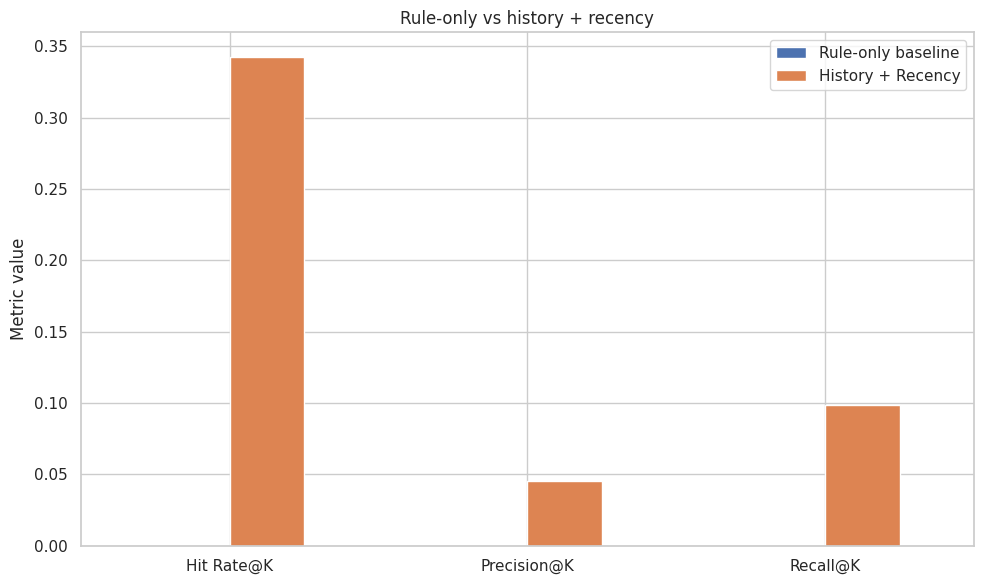

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

In [19]:
# Visual comparison of the most important quality metrics.
metric_names = [
    f"hit_rate@{TOP_K}",
    f"precision@{TOP_K}",
    f"recall@{TOP_K}",
]

plot_df = comparison.loc[metric_names].copy()

ax = plot_df.plot(
    kind="bar",
    figsize=(10, 6),
)

ax.set_ylabel("Metric value")
ax.set_title("Rule-only vs history + recency")
ax.set_xticklabels(
    ["Hit Rate@K", "Precision@K", "Recall@K"],
    rotation=0,
)

plt.tight_layout()
plt.show()

## 13. Inspect a recommendation explanation

For an academic prototype, recommendations should be explainable.

A recommendation can be explained using:

1. **Basket association:** the current basket matched an observed association rule.
2. **Customer history:** the customer has purchased the product previously.
3. **Recency:** the customer's previous purchase was relatively recent.
4. **Reorder tendency:** the product has appeared repeatedly in the customer's historical orders.

This is preferable to presenting a black-box score without evidence.

In [20]:
def explain_recommendation(user_id, items, k=TOP_K):
    recs = recommend_personalized(
        user_id,
        items,
        k=k,
    )

    if recs.empty:
        return recs

    recs = recs.copy()

    def explanation(row):
        reasons = [
            f"rule confidence={row.confidence:.2f}",
            f"lift={row.lift:.2f}",
        ]

        if row.frequency_ratio > 0:
            reasons.append(
                f"customer bought it in "
                f"{row.frequency_ratio:.0%} of previous orders"
            )

        if pd.notna(row.recency_days):
            reasons.append(
                f"last purchased about "
                f"{row.recency_days:.0f} days ago"
            )

        if row.reorder_rate > 0:
            reasons.append(
                f"reorder signal={row.reorder_rate:.2f}"
            )

        return "; ".join(reasons)

    recs["explanation"] = recs.apply(
        explanation,
        axis=1,
    )

    return recs[
        [
            "product",
            "personalized_score",
            "rule_score",
            "confidence",
            "lift",
            "frequency_ratio",
            "reorder_rate",
            "recency_days",
            "explanation",
        ]
    ]

display(
    explain_recommendation(
        example_user,
        example_basket_ids,
        k=TOP_K,
    )
)

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

,product,personalized_score,rule_score,confidence,lift,frequency_ratio,reorder_rate,recency_days,explanation
0,Bag of Organic Bananas,0.099576,0.008698,0.164804,1.136690,0.222222,0.5,83.0,rule confidence=0.16; lift=1.14; customer boug...
1,Organic Strawberries,0.004362,0.007271,0.138268,1.284001,0.000000,0.0,NaN,rule confidence=0.14; lift=1.28
2,Organic Hass Avocado,0.002794,0.004657,0.103352,1.267151,0.000000,0.0,NaN,rule confidence=0.10; lift=1.27


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

# 14. Scalability and computational analysis

### Apriori

Apriori repeatedly generates and evaluates candidate itemsets. Its candidate space can grow rapidly as:

- number of products increases,
- basket size increases,
- minimum support decreases.

In the worst case, the itemset search space is exponential in the number of distinct items.

### FP-Growth

FP-Growth reduces explicit candidate generation by constructing a compressed FP-tree. It is often a stronger frequent-pattern baseline for larger transaction collections, but memory use can still become significant.

### Recommendation layer

Association-rule retrieval is relatively interpretable, but a production system would usually need:

- candidate filtering,
- inventory/availability constraints,
- store/location context,
- price/promotion signals,
- customer preferences,
- learned ranking,
- low-latency retrieval,
- distributed computation,
- online experimentation.

### Why this prototype is bounded

This notebook deliberately uses:

- a sampled number of orders,
- a top-product vocabulary,
- maximum itemset length,
- sparse storage.

Those controls make the academic experiment feasible on Colab/CPU.

In [21]:
# Simple empirical scalability table for the current sample.
# This is descriptive, not a theoretical complexity proof.

scalability_summary = pd.DataFrame({
    "factor": [
        "Mining orders",
        "Candidate products",
        "Minimum support",
        "Maximum itemset length",
        "Apriori runtime (s)",
        "FP-Growth runtime (s)",
        "Sparse basket density",
    ],
    "value": [
        mining_top.order_id.nunique(),
        mining_top.product_id.nunique(),
        MIN_SUPPORT,
        MAX_ITEMSET_LEN,
        apriori_seconds,
        fpgrowth_seconds,
        density,
    ],
})

display(scalability_summary)

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

,factor,value
0,Mining orders,24423.000000
1,Candidate products,250.000000
2,Minimum support,0.003000
3,Maximum itemset length,3.000000
4,Apriori runtime (s),0.671091
5,FP-Growth runtime (s),42.899400
6,Sparse basket density,0.016664


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

# 15. Responsible AI and data considerations

A real grocery recommendation system can affect what customers see and buy. The prototype should therefore consider:

- **Privacy:** minimize personally identifiable information and use aggregate identifiers where possible.
- **Exposure bias:** popular products can dominate recommendation metrics.
- **Availability:** never recommend products that are unavailable to the customer.
- **Fairness:** monitor whether certain products, brands, stores, or customer groups receive systematically different exposure.
- **Sensitive inference:** avoid using grocery behavior to infer sensitive personal attributes.
- **Feedback loops:** recommendations influence future purchases, which can reinforce existing popularity patterns.
- **Transparency:** provide understandable reasons for recommendations where appropriate.
- **Evaluation:** use offline metrics plus controlled online experiments before claiming business impact.

# 16. Industrial interpretation and Instacart connection

This notebook should be presented as a **course-aligned academic prototype**, not as a reconstruction of Instacart's private production stack.

The conceptual mapping is:

| Project layer | Purpose |
|---|---|
| Frequent itemset mining | Discover recurring product combinations |
| Association rules | Retrieve complementary candidate products |
| Customer history | Personalize candidates |
| Recency | Prioritize products relevant to recent behavior |
| Reorder signal | Capture repeat-purchase tendency |
| Ranking score | Combine global association and customer-specific evidence |
| Held-out evaluation | Test whether recommendations recover future purchases |

Instacart's public material can be used in the report to investigate its real recommendation/discovery architecture. The exact production algorithms should only be attributed to Instacart when supported by a credible public source.

# 17. What this notebook demonstrates for the IA-2 problem

### Approved problem statement

**Identifying complementary and potentially missing grocery products in a customer's shopping basket using frequent itemset mining, association rules, purchase history, and recency-aware recommendation.**

### Direct implementation mapping

| Required concept | Implemented? |
|---|---|
| Complementary products | ✅ Association-rule candidates |
| Potentially missing products | ✅ Products associated with basket but absent from it |
| Frequent itemset mining | ✅ Apriori + FP-Growth |
| Association rules | ✅ Support, confidence, lift |
| Customer shopping basket | ✅ Order-level basket |
| Purchase history | ✅ Customer-product history |
| Frequency | ✅ Previous-order frequency |
| Reorder behavior | ✅ Reorder tendency |
| Recency | ✅ Days since previous purchase |
| Personalized ranking | ✅ Rule + history + recency score |
| Next-basket prediction | ✅ Held-out last prior order |
| Evaluation | ✅ Hit@K, Precision@K, Recall@K, coverage, diversity |
| Scalability analysis | ✅ |
| Responsible AI | ✅ |

**Therefore, the notebook is directly aligned with the approved problem statement.**

# 18. Limitations and future improvements

### Current limitations

1. The public dataset is historical and does not represent all current Instacart users or products.
2. The prototype restricts the vocabulary to popular products for computational feasibility.
3. The scoring weights are manually selected rather than learned.
4. The evaluation uses next-basket overlap rather than real business outcomes.
5. Inventory, price, promotion, store, location, dietary preferences, and substitutions are not fully modeled.
6. Association rules are useful for candidate generation but are not sufficient as a complete production recommendation system.
7. The recency calculation is based on reconstructed elapsed time from the public order-history fields.

### Strong future improvements

- Learn ranking weights using logistic regression, gradient boosting, or a neural ranker.
- Add sequential pattern mining for ordered purchase behavior.
- Add product/category embeddings.
- Build a product co-occurrence graph.
- Add store/inventory/price context.
- Add diversity and novelty objectives.
- Compare against popularity and personalized-frequency baselines.
- Test different recency decay functions.
- Use cross-validation across users/time windows.
- Explore transformer/LLM-based semantic discovery as a separate retrieval/ranking layer.

# 19. Final conclusion

Frequent itemset mining provides an interpretable way to discover products that commonly occur together. Association rules convert these patterns into complementary-product candidates.

However, global co-occurrence alone does not answer the complete business problem. By incorporating a customer's purchase history, reorder behavior, and recency, the prototype moves from **generic basket completion** toward **personalized and recency-aware basket completion**.

The final architecture is therefore:

**Current Basket → Frequent Patterns → Association Candidates → Customer History → Recency/Reorder Signals → Personalized Ranking → Complementary/Potentially Missing Products → Held-out Evaluation**

This layered design is the central contribution of the notebook.

# 20. Sources to verify and cite in the technical report

1. Instacart Docs — Recommendations  
   https://docs.instacart.com/storefront/concepts/recommendations/

2. Instacart — 3 Million Instacart Orders, Open Sourced  
   https://tech.instacart.com/3-million-instacart-orders-open-sourced-d40d29ead6f2

3. Kaggle — Instacart Market Basket Analysis dataset  
   https://www.kaggle.com/competitions/instacart-market-basket-analysis/data

4. Instacart — Supercharging ML/AI Foundations at Instacart  
   https://company.instacart.com/tech-innovation/supercharging-ml-ai-foundations-at-instacart

5. Instacart — Distributed Machine Learning  
   https://company.instacart.com/tech-innovation/distributed-machine-learning-at-instacart

6. Instacart — Our Early Journey to Transform Instacart's Discovery Recommendations with LLMs  
   https://company.instacart.com/tech-innovation/our-early-journey-to-transform-instacart-s-discovery-recommendations-with-llms

7. Agrawal et al. — Mining Association Rules Between Sets of Items in Large Databases (1993)  
   https://doi.org/10.1145/170035.170072

8. Han et al. — Mining Frequent Patterns without Candidate Generation (2000)  
   https://doi.org/10.1145/342009.335372

# 21. AI usage declaration

ChatGPT/Codex was used for literature-search planning, code scaffolding, explanations, debugging support, and editorial review. Students should execute the notebook, inspect the outputs, understand the algorithms and results, verify all external claims against the cited sources, and adapt this declaration to accurately describe their own use.

**Do not claim that Apriori or FP-Growth are Instacart's production algorithms unless a cited source explicitly establishes that fact.**